# Fine-Tuned Model: Validation Threshold Recalibration

This notebook recalibrates the binary and human-review thresholds for the fine-tuned MobileNetV2 model. All decisions are based exclusively on the validation split. The reserved test split is not evaluated.

## Selection rules

1. Select the binary threshold that maximizes validation F1 among candidates with defective recall of at least 90%.
2. Set the lower human-review boundary to the minimum defective validation probability. Values strictly below it may be automatically marked Good.
3. Select the lowest upper boundary above the lower boundary that achieves at least 90% defective precision.
4. Predictions between the two boundaries require human review.

These are empirical validation estimates, not guarantees, because the validation set is small.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
MIN_RECALL = 0.90
MIN_AUTO_DEFECT_PRECISION = 0.90
PROJECT_ROOT = Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT / 'data/processed/tile/manifests/tile_supervised_splits.csv'
MODEL_PATH = PROJECT_ROOT / 'outputs/models/milestone4/mobilenetv2_finetuned_standard_best.keras'
ANALYSIS_DIR = PROJECT_ROOT / 'outputs/analysis/milestone5'
FIGURE_DIR = PROJECT_ROOT / 'outputs/figures/milestone5'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True); FIGURE_DIR.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
assert manifest.groupby('group_id')['split'].nunique().max() == 1
assert manifest.groupby('sha256')['split'].nunique().max() == 1
validation = manifest.loc[manifest['split'].eq('validation')].copy().reset_index(drop=True)
reserved_test_count = int(manifest['split'].eq('test').sum())
assert len(validation) == 54

def load_image(path):
    image = tf.io.decode_png(tf.io.read_file(path), channels=3)
    return tf.cast(tf.image.resize(image, IMAGE_SIZE, antialias=True), tf.float32)
validation_ds = tf.data.Dataset.from_tensor_slices(validation['source_path'].astype(str).to_numpy()).map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
y_true = validation['binary_label'].astype(int).to_numpy()
probability = model.predict(validation_ds, verbose=0).reshape(-1)
assert len(probability) == len(validation)
print('Validation images:', len(validation)); print('Defective:', int(y_true.sum())); print('Reserved test images (not evaluated):', reserved_test_count)

Validation images: 54
Defective: 14
Reserved test images (not evaluated): 51


In [3]:
def metrics_at(threshold):
    pred = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    return {'threshold': float(threshold), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'accuracy': accuracy_score(y_true,pred), 'precision': precision_score(y_true,pred,zero_division=0), 'recall': recall_score(y_true,pred,zero_division=0), 'f1': f1_score(y_true,pred,zero_division=0)}
candidates = np.unique(np.r_[np.linspace(0,1,1001), probability])
sweep = pd.DataFrame([metrics_at(t) for t in candidates])
eligible = sweep.loc[sweep['recall'].ge(MIN_RECALL)].copy()
selected = eligible.sort_values(['f1','precision','threshold'], ascending=[False,False,False]).iloc[0]
selected_threshold = float(selected['threshold'])
default_metrics = metrics_at(0.5); selected_metrics = metrics_at(selected_threshold)
print('Default:', default_metrics); print('Selected:', selected_metrics)

Default: {'threshold': 0.5, 'tn': 39, 'fp': 1, 'fn': 2, 'tp': 12, 'accuracy': 0.9444444444444444, 'precision': 0.9230769230769231, 'recall': 0.8571428571428571, 'f1': 0.8888888888888888}
Selected: {'threshold': 0.1526661366224289, 'tn': 37, 'fp': 3, 'fn': 0, 'tp': 14, 'accuracy': 0.9444444444444444, 'precision': 0.8235294117647058, 'recall': 1.0, 'f1': 0.9032258064516129}


In [4]:
low_threshold = float(probability[y_true == 1].min())
upper = sweep.loc[(sweep['threshold'] > low_threshold) & (sweep['precision'] >= MIN_AUTO_DEFECT_PRECISION) & (sweep['tp'] > 0)].sort_values('threshold')
high_threshold = float(upper.iloc[0]['threshold']) if len(upper) else selected_threshold
binary_pred = (probability >= selected_threshold).astype(int)
decision = np.where(probability < low_threshold, 'Good', np.where(probability >= high_threshold, 'Defective', 'Needs Human Review'))
results = validation[['relative_path','source_path','binary_class','binary_label','defect_type']].copy()
results['predicted_probability_defective'] = probability
results['predicted_class_binary'] = np.where(binary_pred == 1, 'defective', 'good')
results['final_decision'] = decision
results['true_label'] = results['binary_class']
results['correct_or_incorrect'] = np.where(binary_pred == y_true, 'correct', 'incorrect')
results['error_type'] = np.select([(y_true==0)&(binary_pred==1),(y_true==1)&(binary_pred==0)], ['false_positive','false_negative'], default='correct')
review_mask = decision == 'Needs Human Review'
auto_mask = ~review_mask
auto_correct = np.where(decision[auto_mask]=='Defective',1,0) == y_true[auto_mask]
human = {'low_threshold': low_threshold, 'high_threshold': high_threshold, 'review_count': int(review_mask.sum()), 'review_rate': float(review_mask.mean()), 'automatic_coverage': float(auto_mask.mean()), 'automatic_accuracy': float(auto_correct.mean()), 'missed_defects_as_automatic_good': int(((decision=='Good')&(y_true==1)).sum()), 'automatic_defective_precision': float(precision_score(y_true, decision=='Defective', zero_division=0))}
print('Human review:', human); print(results['final_decision'].value_counts())
display(results.loc[results['error_type'].ne('correct'), ['relative_path','defect_type','predicted_probability_defective','error_type','final_decision']])

Human review: {'low_threshold': 0.1526661366224289, 'high_threshold': 0.439, 'review_count': 4, 'review_rate': 0.07407407407407407, 'automatic_coverage': 0.9259259259259259, 'automatic_accuracy': 0.98, 'missed_defects_as_automatic_good': 0, 'automatic_defective_precision': 0.9230769230769231}
final_decision
Good                  37
Defective             13
Needs Human Review     4
Name: count, dtype: int64


,relative_path,defect_type,predicted_probability_defective,error_type,final_decision
32,train/good/078.png,good,0.438425,false_positive,Needs Human Review
43,train/good/164.png,good,0.188034,false_positive,Needs Human Review
45,train/good/168.png,good,0.721655,false_positive,Defective


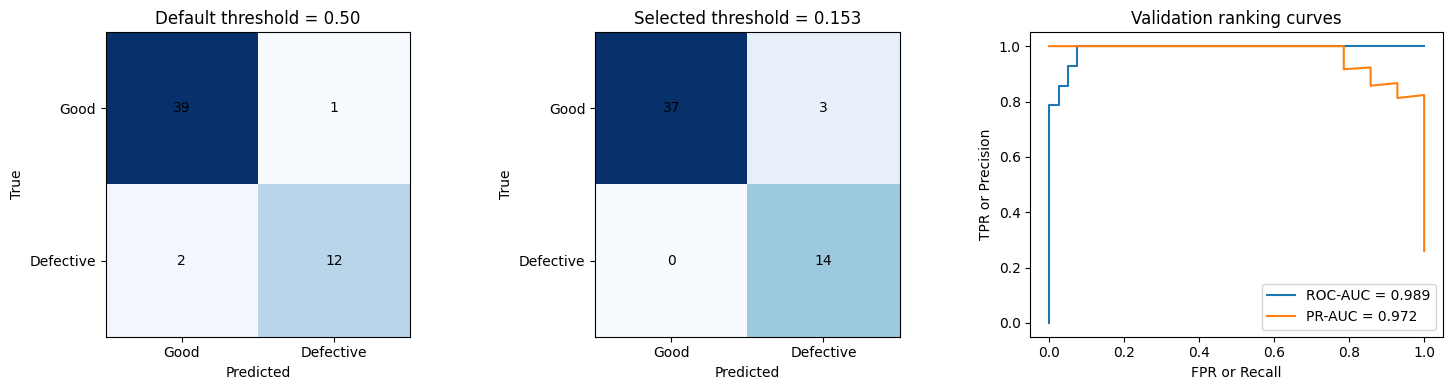

{
  "model": "mobilenetv2_finetuned_standard_best.keras",
  "selection_split": "validation",
  "validation_images": 54,
  "validation_defective_images": 14,
  "default_threshold_metrics": {
    "threshold": 0.5,
    "tn": 39,
    "fp": 1,
    "fn": 2,
    "tp": 12,
    "accuracy": 0.9444444444444444,
    "precision": 0.9230769230769231,
    "recall": 0.8571428571428571,
    "f1": 0.8888888888888888
  },
  "selected_binary_threshold": 0.1526661366224289,
  "selected_threshold_metrics": {
    "threshold": 0.1526661366224289,
    "tn": 37,
    "fp": 3,
    "fn": 0,
    "tp": 14,
    "accuracy": 0.9444444444444444,
    "precision": 0.8235294117647058,
    "recall": 1.0,
    "f1": 0.9032258064516129
  },
  "validation_roc_auc": 0.9892857142857143,
  "validation_pr_auc": 0.9723766429648781,
  "human_review": {
    "low_threshold": 0.1526661366224289,
    "high_threshold": 0.439,
    "review_count": 4,
    "review_rate": 0.07407407407407407,
    "automatic_coverage": 0.9259259259259259,
    "

In [5]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, threshold, title in [(axes[0],0.5,'Default threshold = 0.50'),(axes[1],selected_threshold,f'Selected threshold = {selected_threshold:.3f}')]:
    cm = confusion_matrix(y_true, probability>=threshold, labels=[0,1]); image=ax.imshow(cm,cmap='Blues'); ax.set(title=title,xlabel='Predicted',ylabel='True',xticks=[0,1],yticks=[0,1],xticklabels=['Good','Defective'],yticklabels=['Good','Defective']);
    for (i,j),value in np.ndenumerate(cm): ax.text(j,i,str(value),ha='center',va='center')
fpr,tpr,_=roc_curve(y_true,probability); precision_curve,recall_curve,_=precision_recall_curve(y_true,probability)
axes[2].plot(fpr,tpr,label=f'ROC-AUC = {roc_auc_score(y_true,probability):.3f}'); axes[2].plot(recall_curve,precision_curve,label=f'PR-AUC = {average_precision_score(y_true,probability):.3f}'); axes[2].set(title='Validation ranking curves',xlabel='FPR or Recall',ylabel='TPR or Precision'); axes[2].legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR/'fine_tuned_validation_thresholds.png',dpi=160,bbox_inches='tight'); plt.show()
results.to_csv(ANALYSIS_DIR/'fine_tuned_validation_predictions_and_human_review.csv',index=False)
sweep.to_csv(ANALYSIS_DIR/'fine_tuned_validation_threshold_sweep.csv',index=False)
frozen = json.loads((PROJECT_ROOT/'outputs/analysis/milestone3/validation_threshold_selection_summary.json').read_text(encoding='utf-8'))
summary = {'model': MODEL_PATH.name, 'selection_split':'validation', 'validation_images':len(validation), 'validation_defective_images':int(y_true.sum()), 'default_threshold_metrics':default_metrics, 'selected_binary_threshold':selected_threshold, 'selected_threshold_metrics':selected_metrics, 'validation_roc_auc':roc_auc_score(y_true,probability), 'validation_pr_auc':average_precision_score(y_true,probability), 'human_review':human, 'comparison_with_frozen_model': {'frozen_selected_metrics':frozen['selected_threshold_metrics'], 'fine_tuned_selected_metrics':selected_metrics}, 'test_evaluated':False}
(ANALYSIS_DIR/'fine_tuned_threshold_selection_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print(json.dumps(summary,indent=2))

## Interpretation

The selected thresholds and review rates describe this validation set only. After the model and operating policy are fixed, the reserved test split should be used once for unbiased final reporting.